# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 7: Validación y Estabilidad de Modelos.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
import warnings
import joblib
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
warnings.filterwarnings("ignore")

np.random.seed(42)

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s07")
src_path = os.path.join(absolute_path, "src", "s07")
model_path = os.path.join(absolute_path, "models", "s07")
figure_path = os.path.join(absolute_path, "figuras", "s07")
sys.path.insert(0, src_path)

from datetime import datetime
from preprocessing import Preprocessing
from feature_engineering import FeatureEngineering
from modeling import Modeling

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 🎯 **Objetivos de la sesión**

La parte de modelamiento no es el final del camino, la validación de las herramientas analíticas de credit scoring son relevantes para **mitigar el riesgo de modelo** y cumplir con la normativa del regulador en banca. 

Abordaremos los siguientes puntos:
- **Internal Validation**:
    - ¿Qué es? 
    - ¿Cómo se hace? 
    - ¿Cuál es su aporte?
- **Nivel de Riesgo del Modelo**: Evaluar el modelo y emitir una opinión independiente.
- **Estabilidad del Modelo**: Monitoriar la estabilidad de las variables y el desempeño del modelo.

# 💙 **1. Internal Validation** 

Los equipos de Validación Interna de Riesgos son la segunda línea de defensa dentro del proceso de creación e implementación de un modelo de riesgo. La función más importante de los equipos de Validación Interna es **MITIGAR EL RIESGO DE MODELO**.

Asimismo, los equipos de Validación Interna deben gozar de **independencia absoluta en el proceso de validación de los modelos**. Muchas veces se trabaja de manera paralela con el equipo de **Desarrollo de Modelos** definiendo fechas de entregables y solucionando inconsistencias encontradas en cada etapa de la validación (de ser posible y en base a la severidad).

### 📃​ **Principios de la Validación Interna**:
- **Completitud** -> Todos los modelos relevantes utilizados en la gestión del riesgo.
- **Alcance** -> Debe evaluar el adecuado comportamiento del modelo empleando métodos cuantitativos y cualitativos.
- **Independiente** -> Garantizar la independencia de funciones respecto de intervinientes en el desarrollo para evitar que la opinión del riesgo de modelo pueda estar afectada por influencias indebidas.
- **Analítica** -> Debe cuestionar de forma efectiva todas las decisiones tomadas durante las distintas fases del ciclo de desarrollo del modelo buscando **exactitud, robustez y estabilidad**

### ✅​ **Tipología de trabajos de Validación Interna**
- **Validaciones Recurrentes** de modelos, tanto regulatorios como no regulatorios.
- **Ratificación del nivel de materialidad** cuando existe cambios introducidos a los modelos y se necesita evaluar el impacto final.
- **Validación Inicial** de modelos para la aprobación de la implementación de nuevos modelos.
- **Emisión de Opiniones** a efectos de comités sobre el nivel de riesgo de los modelos.

**Nota**: La periodicidad de las validación depende de la importancia del modelo, exigencias regulatorios o cambios en la gestión.
  
### 🔠 **Puntos de la Validación y Aporte**
El equipo de Validación Interna debe hacer una evaluación completa del modelo. A continuación los puntos más importantes:
- **Base de Datos y Perímetro**: Verificar la correcta construcción de las bases de datos utilizadas en el desarrollo, las consideraciones tomadas en la definición del perímetro final y garantizar la calidad de los datos.
- **Metodología y Desempeño**: Evaluar si la metodología empleada en el desarrollo del modelo es la más optima en base al problema de negocio y tipo de producto/cliente. Asimismo, el modelo debe ser sometido a pruebas de testing para verificar su desempeño a lo largo del tiempo.
- **Integración a la Gestión**: Verificar el correcto uso de la herramienta por parte del equipo owner de la herramienta. Que se aplique bajo los criterios establecidos (perímetro: Tarjeta de Crédito, Nuevos Clientes, etc.)
- **Documentación**: Validar que el documento metodológico del modelo esté completo y permita que un tercero independiente pueda replicar el modelo con solo la información brindada en el documento.

La importancia de los equipos de Validación Interna radica en buscar mitigar el riesgo de modelo y tener herramientas mucho más sólidas en términos estadísticos y matemáticos alineadas a los criterios de negocio evitando el error humano o computacional.

<img src="../../figuras/s07/vi_table.png" width="1000"/>


# **2. Preprocesamiento de Datos**

**Data Preprocessing**

En esta etapa se ejecuta el **preprocesamiento del dataset** antes del modelado. La lógica completa se encuentra implementada en el archivo: 
```
src/preprocessing.py
```
El pipeline realiza las siguientes transformaciones principales:
- **Carga de datos** desde el directorio `raw_data_dir`.
- **Eliminación de variables con data leakage**, es decir, variables que contienen información posterior al evento de default o derivadas del target:
  - `DPD_30`, `DPD_60`, `DPD_90`
  - `Worst_Current_Status`
  - `Months_Since_Most_Recent_Delinquency`
- **Creación de la variable temporal `month`** a partir de `Application_Date`, la cual permitirá realizar análisis de estabilidad del modelo y validaciones Out-of-Time (OOT).
- **Eliminación de variables no informativas** como identificadores (`Customer_ID`) y fechas originales.
- **Eliminación de duplicados** para evitar sesgos en el entrenamiento.
- **Tratamiento de valores faltantes**:
  - Columnas con más de **70% de missing values** son eliminadas.
  - Variables numéricas se imputan con **mediana**.
  - Variables categóricas se imputan con **moda**.
- **Codificación ordinal de variables categóricas** (`Education_Level`, `Marital_Status`).
- **Transformación logarítmica (`log1p`) en variables monetarias** para reducir asimetrías y la influencia de valores extremos.

Finalmente, el dataset limpio es guardado en `output_data_dir`, generando un **dataset listo para feature engineering y modelado**.

In [2]:
pp = Preprocessing(
    raw_data_dir    = data_path,
    output_data_dir = data_path,
    raw_filename    = 'credit_data.csv',
)

df = pp.run_all()
pp.report()

[load]  2,000 rows × 29 cols loaded from 'c:\Users\Enzo\Documents\PHYTON\Credit_Scoring\CreditScoring\data\s07\credit_data.csv'
[leak]  Dropped leakage columns: ['DPD_30', 'DPD_60', 'DPD_90', 'Worst_Current_Status', 'Months_Since_Most_Recent_Delinquency']
[create] Created 'month' column from 'Application_Date'.
[clean] Dropped non-feature cols: ['Customer_ID', 'Application_Date']
[dtype] Integer dtypes enforced.
[clean] Duplicates removed: 0 (remaining: 2,000)
[enc]   Education_Level → ordinal {HS:0, Grad:1, PG:2}
[enc]   Marital_Status  → ordinal {Single:0, Married:1, Divorced:2, Widowed:3}
[trf]   log1p applied → ['log_Income_INR', 'log_Loan_Amount', 'log_Savings_Account_Balance', 'log_Checking_Account_Balance', 'log_Total_Credit_Limit', 'log_Total_Current_Balance', 'log_Max_Credit_Exposure']
[clean] Column names standardised.

✅  Preprocessed data saved → 'c:\Users\Enzo\Documents\PHYTON\Credit_Scoring\CreditScoring\data\s07\preprocessed_credit_data.csv'
    Shape: 2,000 rows × 30 co

In [3]:
df.head()

,age,income_inr,employment_years,marital_status,education_level,credit_history_length,outstanding_loans,loan_amount,loan_tenure_months,savings_account_balance,checking_account_balance,no_of_open_accounts,no_of_closed_accounts,total_credit_limit,total_current_balance,credit_utilization_ratio,no_of_inquiries_6m,no_of_inquiries_12m,max_credit_exposure,oldest_trade_open_months,newest_trade_open_months,default,month,log_income_inr,log_loan_amount,log_savings_account_balance,log_checking_account_balance,log_total_credit_limit,log_total_current_balance,log_max_credit_exposure
0,59,167371,32,1,1,30,4,554141,36,72105,15594,7,6,217242,41275,0.19,1,2,230905,363,186,0,2025-02,12.027974,13.225176,11.185893,9.654706,12.288772,10.628036,12.349766
1,49,346178,18,1,1,23,0,389864,24,446939,75222,7,7,418320,71114,0.17,2,3,534427,285,6,0,2025-05,12.754711,12.873556,13.010180,11.228212,12.944004,11.172054,13.188952
2,35,267393,10,0,1,16,0,1304251,36,313495,106708,2,3,709140,63822,0.09,1,1,835600,198,50,0,2023-04,12.496479,14.081140,12.655542,11.577861,13.471810,11.063869,13.635907
3,63,444006,26,0,1,26,0,1107690,84,511428,198478,6,8,690045,372624,0.54,0,0,809349,318,305,0,2025-04,13.003596,13.917788,13.144964,12.198439,13.444514,12.828328,13.603987
4,28,254301,4,0,1,4,4,1211953,240,317746,90845,4,0,342719,102815,0.30,0,2,358903,55,46,0,2025-04,12.446278,14.007744,12.669011,11.416921,12.744669,11.540696,12.790810


# **3. Feature Engineering**

En esta etapa se construyen nuevas variables predictivas y se prepara el dataset para el modelado de **Credit Scoring**. La lógica completa se encuentra implementada en:
```
src/s07/feature_engineering.py
```
El pipeline realiza los siguientes pasos principales:

- **Creación de variables derivadas (domain-driven features)** basadas en teoría de riesgo crediticio, principalmente **ratios financieros y comportamentales**, como:
  - `debt_to_income`
  - `installment_to_income`
  - `balance_to_income`
  - `savings_to_loan`
  - `utilization_per_open_account`
  - `account_maturity`
  - `closed_account_ratio`
- **Split temporal Train / Test (Out-of-Time validation)** usando la variable `month`:
  - **Train:** datos anteriores a septiembre 2025  
  - **Test (OOT):** septiembre–diciembre 2025  
  Esto permite evaluar el modelo en un periodo **no visto durante el entrenamiento**, replicando validaciones regulatorias.
- **Filtro de correlación entre variables** eliminando features altamente correlacionadas  
  \(|r| > 0.90\), conservando la variable con **mayor correlación con el target**.
- **Transformación Weight of Evidence (WoE)** aplicada a variables numéricas mediante **binning por cuantiles**.  
  El WoE se **entrena solo en el set de entrenamiento** y luego se aplica a Train y Test para evitar **data leakage**.
- **Cálculo del Information Value (IV)** para cada variable, lo que permite evaluar su poder predictivo y apoyar la **selección de variables** según el valor del IV (>0.02).

El resultado es un dataset transformado con variables **WoE listas para entrenar un modelo de scorecard basado en regresión logística**.

In [4]:
fe = FeatureEngineering(
    input_dir       = data_path,
    output_dir      = data_path,
    input_filename  = 'preprocessed_credit_data.csv',
)
train, test = fe.run_all()

fe.report_split()

[load]  2,000 rows × 30 cols loaded.
[feat]  Derived features created:
        debt_to_income, balance_to_income, savings_to_loan,
        monthly_installment_proxy, installment_to_income,
        inquiry_acceleration, utilization_per_open_account,
        total_accounts, closed_account_ratio,
        credit_hist_months, account_maturity, trade_gap
[split] OOT split  →  Train: 1,785 rows (21.79% default)  |  Test (OOT ≥ 2025-09): 215 rows (22.79% default)
[corr]  Dropped 9 highly correlated features (|r| > 0.9): ['income_inr', 'log_max_credit_exposure', 'oldest_trade_open_months', 'credit_history_length', 'employment_years', 'credit_hist_months', 'log_total_credit_limit', 'loan_amount', 'total_credit_limit']
[woe]   WoE encoding done. IV computed for 31 features.

── IV Summary ───────────────────────────────────────────────────
                     Feature     IV Strength
    credit_utilization_ratio 0.0902     Weak
utilization_per_open_account 0.0662     Weak
    newest_trade_open_mo

# **4. Modeling**

En esta etapa se entrena y evalúa el **modelo de Credit Scoring** utilizando **Regresión Logística**, siguiendo prácticas estándar utilizadas en la industria financiera y procesos de **Model Risk Management**. La lógica completa se encuentra implementada en:
```
src/s07/modeling.py
```

El pipeline realiza los siguientes pasos principales:

- **Carga de los datasets transformados** (`train_fe.csv` y `test_fe.csv`) generados en la etapa de *feature engineering*, separando variables predictoras y el **target de default**.
- **Selección automática de variables WoE**, priorizando columnas que comienzan con `woe_`.  
  Si no existen, se utilizan variables numéricas excluyendo el `target` y columnas no predictivas como `month`.
- **Entrenamiento de un modelo de Regresión Logística**, estándar en modelos de **Credit Risk**, utilizando un pipeline que incluye:
  - `StandardScaler`
  - `LogisticRegression` con **class weights** para corregir el desbalance de clases.
- **Optimización de hiperparámetros** mediante **RandomizedSearchCV** con **Stratified K-Fold Cross Validation**, explorando:
  - parámetro de regularización `C`
  - tipo de penalización (`L1` / `L2`)
  - solver del modelo.
- **Ajuste de un threshold óptimo de clasificación**, calculado sobre las probabilidades del set de entrenamiento utilizando la **curva Precision–Recall**, maximizando el **F1-score**.  
  Esto permite mejorar la detección de clientes riesgosos en datasets desbalanceados.
- **Evaluación del modelo en un dataset Out-of-Time (OOT)** para simular desempeño en datos futuros, calculando métricas clave como:
  - **ROC AUC**
  - **Precision**
  - **Recall**
  - **F1 Score**
  - **PR AUC**
  - **Confusion Matrix**

- **Visualización de curvas de evaluación del modelo**, incluyendo:
  - **ROC Curve**
  - **Precision–Recall Curve**
  - **Confusion Matrix**
- **Análisis de coeficientes del modelo**, permitiendo interpretar el impacto de cada variable WoE sobre la probabilidad de default y validar su **sentido económico**.

El resultado es un modelo de **Regresión Logística calibrado y evaluado en datos Out-of-Time**, listo para pasar a la etapa de **validación y análisis de estabilidad del modelo**.

[load]  Train: (1785, 17)  |  Test (OOT): (215, 17)
[load]  Features used (17): ['woe_age', 'woe_savings_account_balance', 'woe_checking_account_balance', 'woe_total_current_balance', 'woe_credit_utilization_ratio', 'woe_max_credit_exposure', 'woe_newest_trade_open_months', 'woe_log_income_inr', 'woe_log_savings_account_balance', 'woe_log_checking_account_balance', 'woe_log_total_current_balance', 'woe_balance_to_income', 'woe_savings_to_loan', 'woe_monthly_installment_proxy', 'woe_utilization_per_open_account', 'woe_total_accounts', 'woe_account_maturity']
[load]  Train default rate: 21.79%  |  Test default rate: 22.79%

[train] Running RandomizedSearchCV (Logistic Regression)...
[train] Best params    : {'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 0.1}
[train] Best CV AUC    : 0.5328
[train] Optimal threshold (max F1 on train): 0.4703

── Test Set Metrics (OOT)  —  threshold = 0.4703 ────────
  ROC AUC          : 0.5377
  PR AUC           : 0.2793
  Recall           

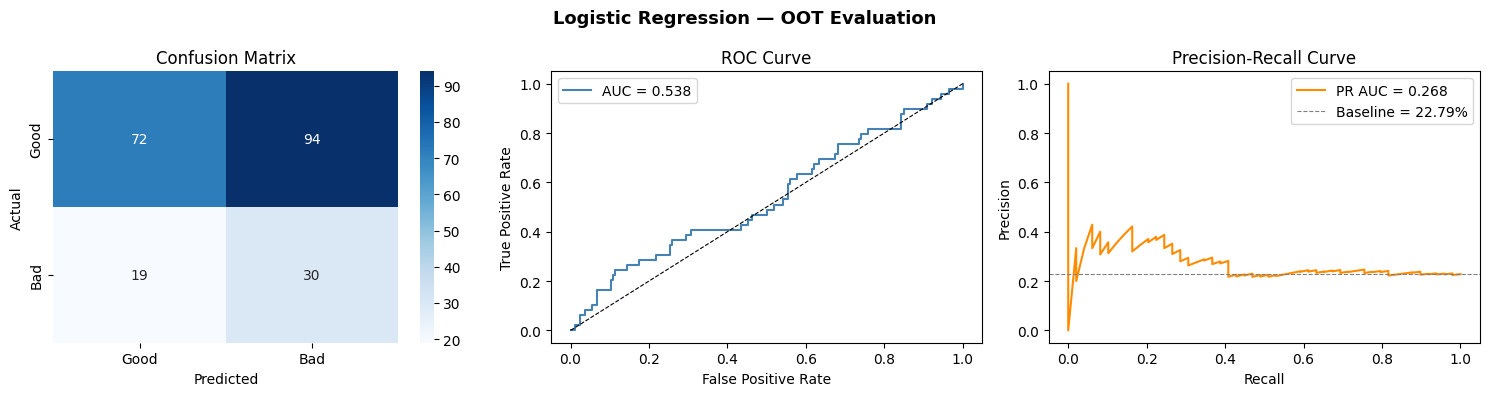

[plot]  Saved → 'c:\Users\Enzo\Documents\PHYTON\Credit_Scoring\CreditScoring\figuras\s07\lr_evaluation.png'


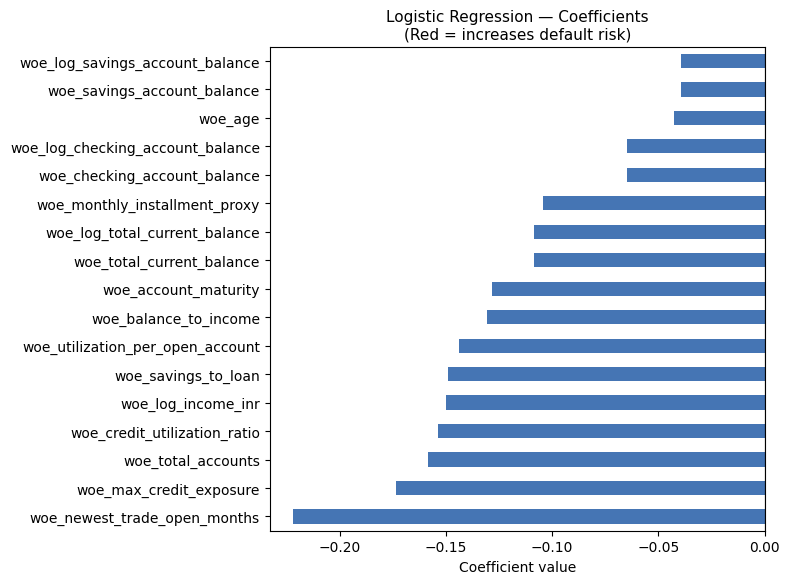

[plot]  Saved → 'c:\Users\Enzo\Documents\PHYTON\Credit_Scoring\CreditScoring\figuras\s07\lr_coefficients.png'
[save]  Predictions saved → 'c:\Users\Enzo\Documents\PHYTON\Credit_Scoring\CreditScoring\data\s07\test_predictions.csv'

✅  Modelling pipeline complete.


In [5]:
mdl = Modeling(
    train_path = os.path.join(data_path, 'train_fe.csv'),
    test_path  = os.path.join(data_path, 'test_fe.csv'),
    output_dir = data_path,
    figure_dir = figure_path,
)

mdl.run_all()

In [6]:
joblib.dump(mdl.best_model, os.path.join(model_path, 'logistic_regression.pkl'))
print('Modelo guardado ✅')

best_model = joblib.load(os.path.join(model_path, 'logistic_regression.pkl'))

Modelo guardado ✅


# **5. Validación del Modelo y Estabilidad**

| # | Análisis | Objetivo |
|---|---|---|
| 1 | **PSI** — Population Stability Index | Detectar deriva en la distribución de variables |
| 2 | **Estabilidad de variables** | Ver tendencias temporales en WoE |
| 3 | **Evolución Gini / AUC** | Monitorear poder discriminatorio en el tiempo |
| 4 | **KS Evolution** | Separación Good/Bad a lo largo del tiempo |
| 5 | **Distribución de Score** | Train vs OOT: ¿el modelo sigue calibrado? |
| 6 | **Bad Rate Evolution** | Evolución del target observado en el tiempo |

In [7]:
TARGET = 'default'

features = mdl.features
train['score'] = mdl.best_model.predict_proba(train[features])[:, 1]
test['score']  = mdl.best_model.predict_proba(test[features])[:, 1]

train['month'] = train['month'].astype(str)
test['month']  = test['month'].astype(str)

OOT_START = test['month'].min()

print(f'Train: {len(train):,} obs | {train["month"].min()} → {train["month"].max()}')
print(f'Test:  {len(test):,}  obs | {test["month"].min()}  → {test["month"].max()}')
print(f'Default rate — Train: {train[TARGET].mean():.2%} | Test: {test[TARGET].mean():.2%}')

Train: 1,785 obs | 2023-01 → 2025-08
Test:  215  obs | 2025-09  → 2025-12
Default rate — Train: 21.79% | Test: 22.79%


## **5.1 PSI: Population Stability Index**

### **¿Qué es?**
El PSI mide **cuánto cambió la distribución** de una variable entre el período de desarrollo (train) y el período de monitoreo (OOT test). Es la métrica estándar de la industria para detectar **deriva poblacional** (*population drift*). Sigue la siguiente fórmula:

$$\text{PSI} = \sum_{i=1}^{n} \left( \text{Actual}_i\% - \text{Esperado}_i\% \right) \times \ln\left( \frac{\text{Actual}_i\%}{\text{Esperado}_i\%} \right)$$

Donde:
- **Esperado** = distribución en train (desarrollo del modelo)
- **Actual** = distribución en OOT (monitoreo)
- Los bins se definen **sobre el train** y se aplican al OOT

| PSI | Semáforo | Acción |
|-----|----------|--------|
| < 0.10 | 🟢 Estable | Sin acción |
| 0.10 – 0.25 | 🟡 Cambio menor | Monitorear de cerca |
| > 0.25 | 🔴 Cambio significativo | Investigar, considerar recalibración |

### **Ventajas**
- Fácil de interpretar y explicar al regulador
- Aplica tanto a variables como al score final
- Es simétrico: detecta tanto si la población mejoró como si empeoró

### **Limitaciones**
- Sensible al número de bins elegido (estándar: 10)
- No indica la **dirección** del cambio, solo la magnitud
- Con muestras pequeñas puede ser inestable
- No captura cambios en la **relación** entre variables y target (para eso: Gini/KS)

In [8]:
PSI_GREEN  = 0.10
PSI_YELLOW = 0.25
N_BINS_PSI = 10

def compute_psi(expected, actual, n_bins=10):
    """PSI = Σ (Actual% - Expected%) × ln(Actual% / Expected%)"""
    _, bin_edges = np.histogram(expected, bins=n_bins) # Divide los valores de expected en n_bins intervalos de ancho similar
    bin_edges[0]  = -np.inf # ningún valor queda fuera de los bins izquierda
    bin_edges[-1] =  np.inf # ningún valor queda fuera de los bins derecha

    # np.histogram(...)[0] devuelve el conteo en cada bin.
    # Se divide por el tamaño de cada muestra → porcentaje por bin.
    # .clip(min=1e-9) evita ceros (para que log no explote).
    exp_pct = (np.histogram(expected, bins=bin_edges)[0] / len(expected)).clip(min=1e-9) 
    act_pct = (np.histogram(actual,   bins=bin_edges)[0] / len(actual)  ).clip(min=1e-9)
    return float(((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum())

def psi_label(psi):
    if psi < PSI_GREEN:  return '✅ Stable'
    if psi < PSI_YELLOW: return '⚠️ Monitor'
    return '🔴 Investigate'

cols_to_check = features + ['score']
psi_records = []

for col in cols_to_check:
    psi_val = compute_psi(train[col].values, test[col].values, N_BINS_PSI)
    psi_records.append({'Feature': col, 'PSI': round(psi_val, 4), 'Status': psi_label(psi_val)})

psi_df = pd.DataFrame(psi_records).sort_values('PSI', ascending=False).reset_index(drop=True)
print(psi_df)

                             Feature     PSI      Status
0                              score  0.1261  ⚠️ Monitor
1              woe_balance_to_income  0.0734    ✅ Stable
2      woe_monthly_installment_proxy  0.0530    ✅ Stable
3                            woe_age  0.0519    ✅ Stable
4                woe_savings_to_loan  0.0518    ✅ Stable
5       woe_credit_utilization_ratio  0.0442    ✅ Stable
6       woe_newest_trade_open_months  0.0436    ✅ Stable
7               woe_account_maturity  0.0387    ✅ Stable
8                 woe_total_accounts  0.0242    ✅ Stable
9       woe_checking_account_balance  0.0232    ✅ Stable
10  woe_log_checking_account_balance  0.0232    ✅ Stable
11  woe_utilization_per_open_account  0.0135    ✅ Stable
12           woe_max_credit_exposure  0.0134    ✅ Stable
13     woe_log_total_current_balance  0.0117    ✅ Stable
14         woe_total_current_balance  0.0117    ✅ Stable
15   woe_log_savings_account_balance  0.0093    ✅ Stable
16       woe_savings_account_ba

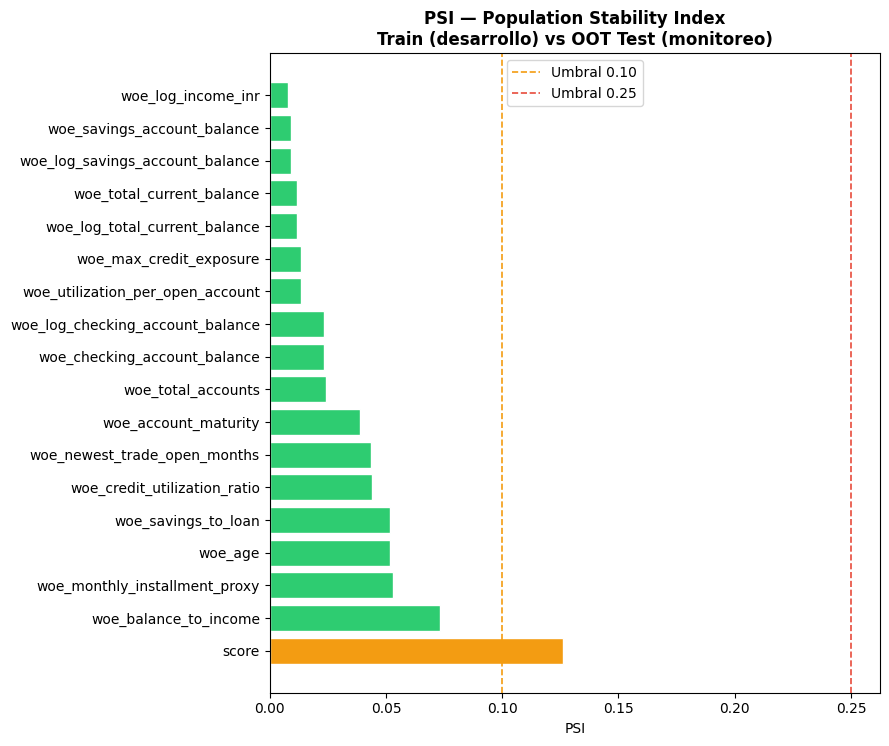

In [9]:
fig, ax = plt.subplots(figsize=(9, max(4, len(psi_df) * 0.42)))

colors = ['#2ecc71' if p < PSI_GREEN else '#f39c12' if p < PSI_YELLOW else '#e74c3c' for p in psi_df['PSI']]

ax.barh(psi_df['Feature'], psi_df['PSI'], color=colors, edgecolor='white')
ax.axvline(PSI_GREEN,  color='#f39c12', linestyle='--', linewidth=1.2, label='Umbral 0.10')
ax.axvline(PSI_YELLOW, color='#e74c3c', linestyle='--', linewidth=1.2, label='Umbral 0.25')
ax.set_title('PSI — Population Stability Index\nTrain (desarrollo) vs OOT Test (monitoreo)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('PSI')
ax.legend()
plt.tight_layout()
plt.show()

## **5.2 Estabilidad de Variables en el Tiempo**

La **media mensual del WoE** de cada variable a lo largo del tiempo (train + OOT).

- Una variable **estable** muestra una línea plana o con **variación aleatoria sin tendencia**.
- Una variable con **tendencia sostenida** (creciente o decreciente) indica un cambio estructural en el perfil de los solicitantes.
- Un **quiebre abrupto** en la línea vertical (inicio del OOT) puede señalar un cambio en la política de originación o en el entorno macroeconómico.

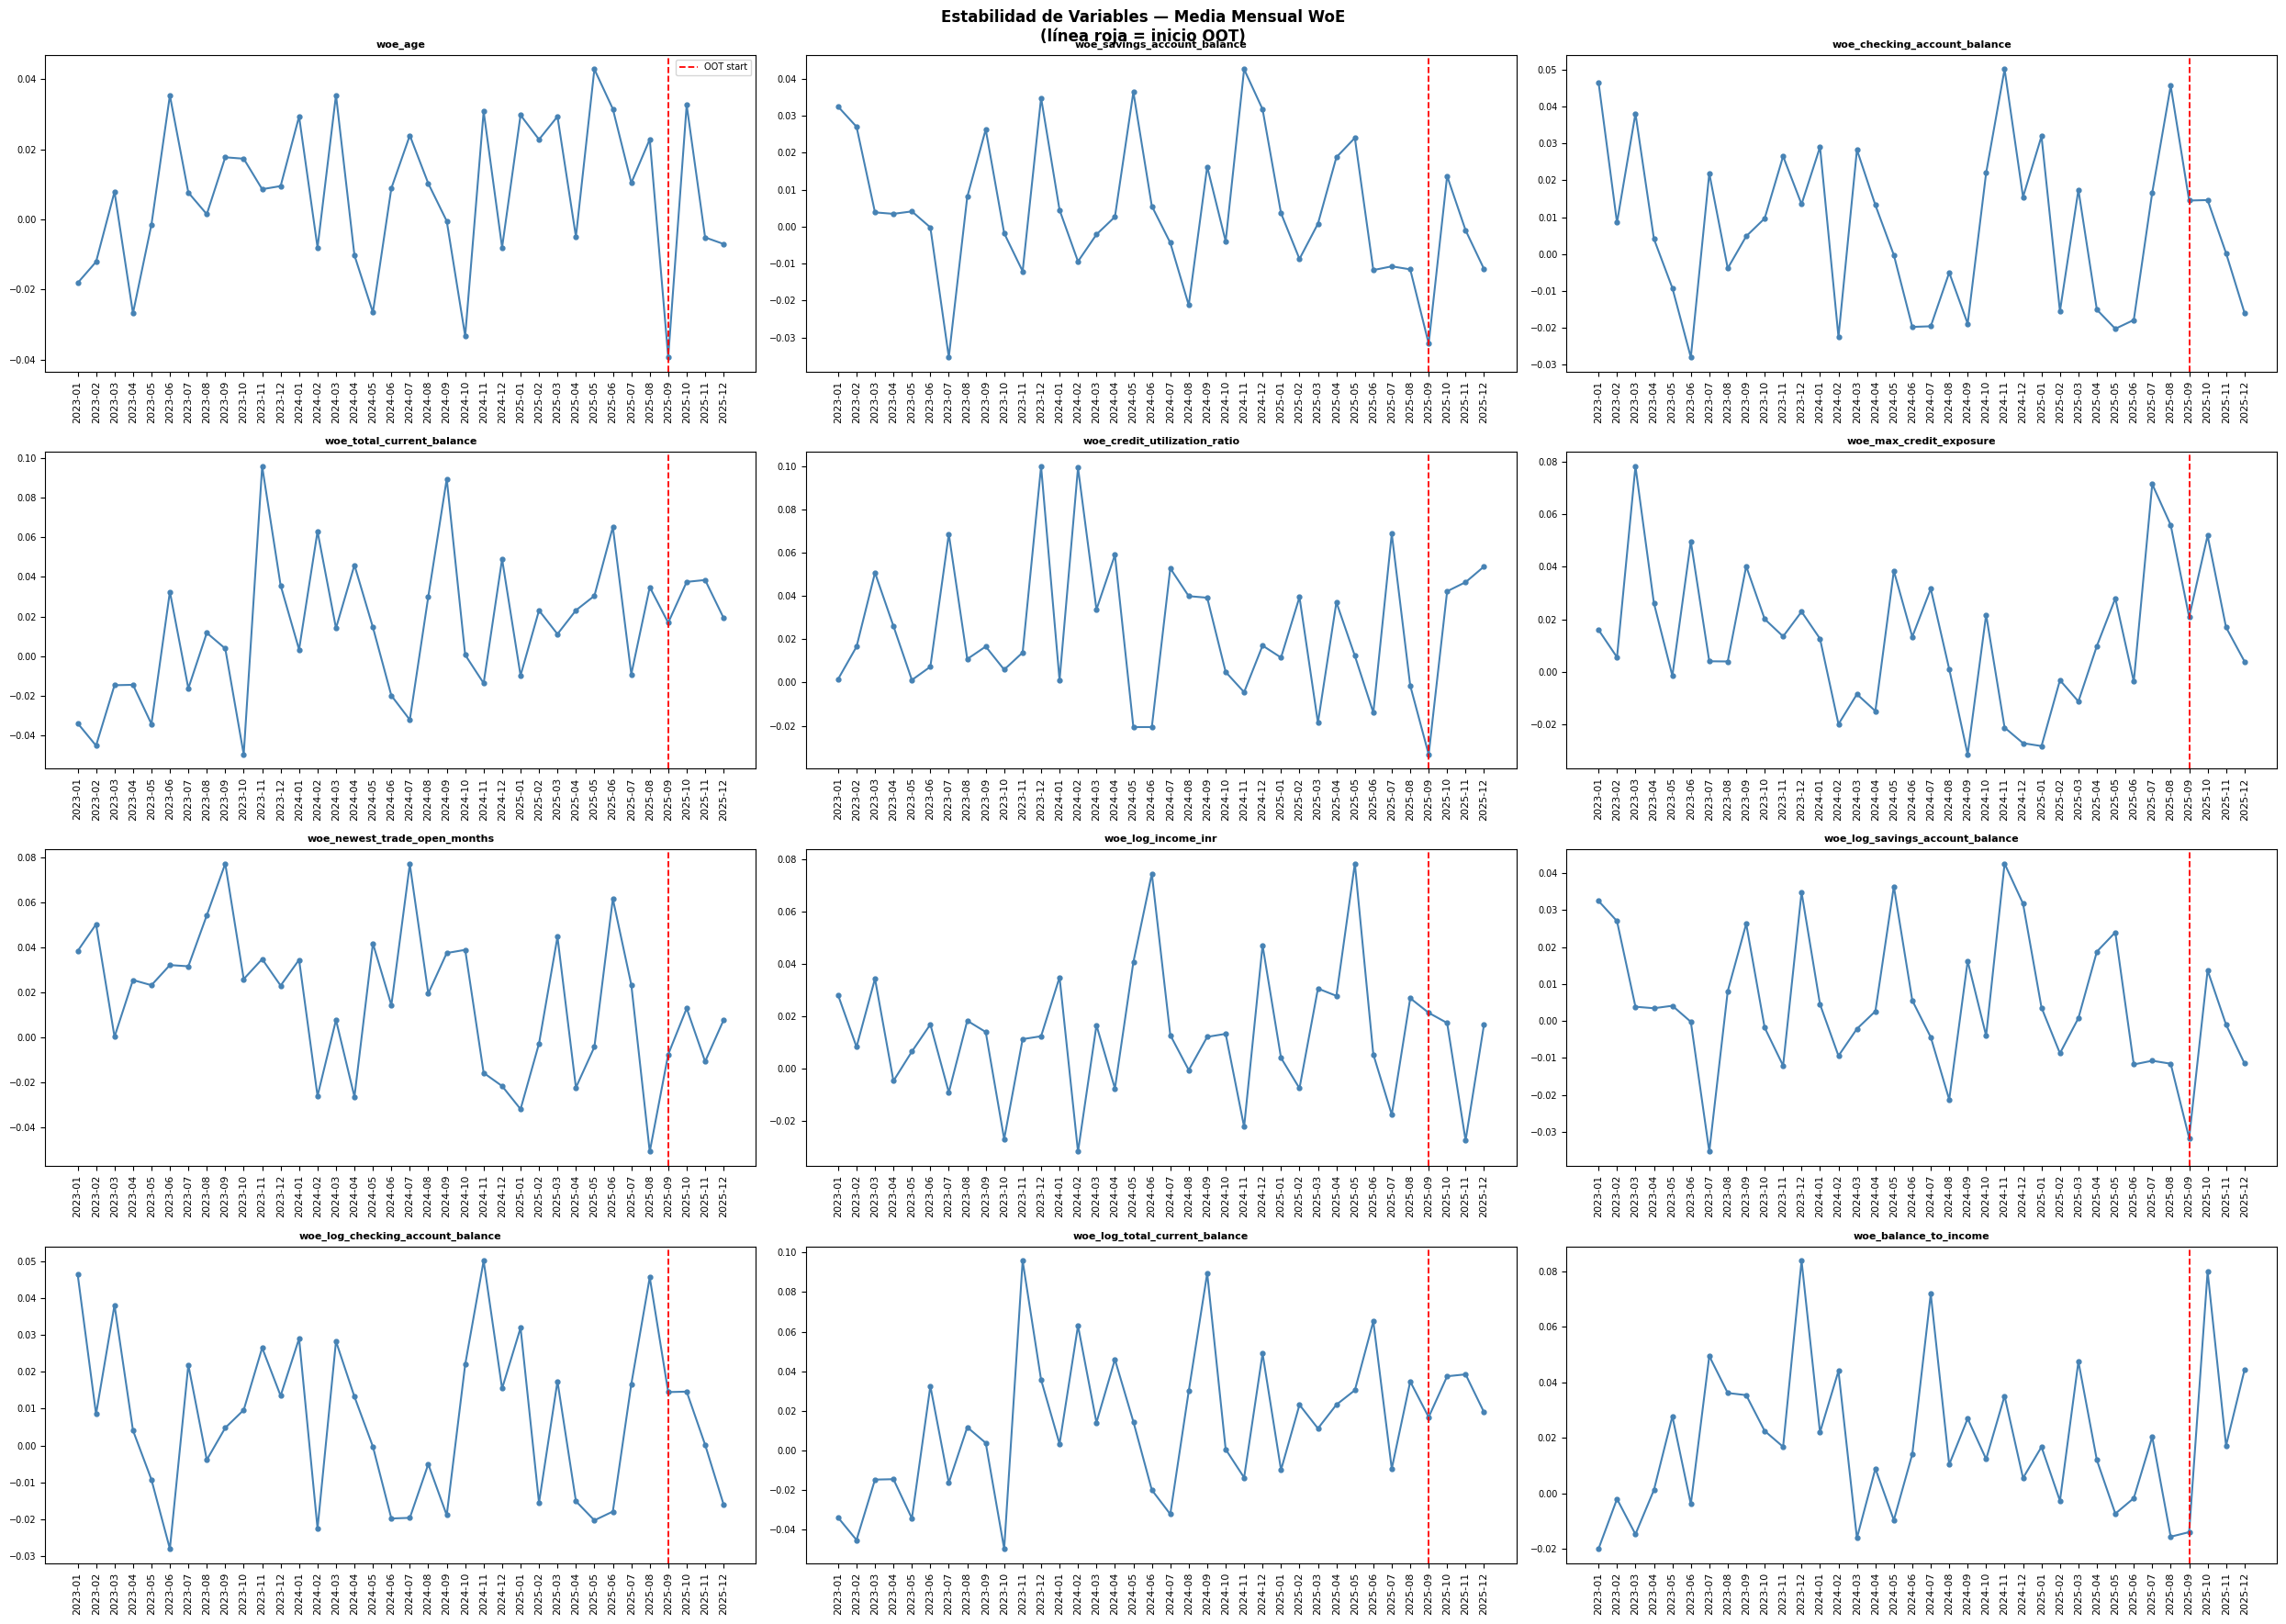

In [10]:
all_data = pd.concat([train.assign(set='Train'), test.assign(set='OOT')]).sort_values('month')

vars_to_plot = features[:12]  # top 9 para visualización
ncols, nrows = 3, (len(vars_to_plot) + 2) // 3

fig, axes = plt.subplots(nrows, ncols, figsize=(25, nrows * 4.5))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    monthly = all_data.groupby('month')[col].mean()
    ax = axes[i]
    ax.plot(monthly.index, monthly.values, marker='o', markersize=3.5,
            linewidth=1.5, color='steelblue')
    ax.axvline(OOT_START, color='red', linestyle='--', linewidth=1.3, label='OOT start')
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Estabilidad de Variables — Media Mensual WoE\n(línea roja = inicio OOT)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## **5.3 Evolución del Gini / AUC en el Tiempo**

**¿Por qué es importante?**
El **Gini** (= 2 × AUC − 1) es la métrica estándar de **poder discriminatorio** bajo Basilea II/III para modelos PD. Mide qué tan bien el modelo separa a los buenos pagadores de los malos.

$$\text{Gini} = 2 \times \text{AUC} - 1$$

**Referencia de umbrales (PD models)**
| Gini | Evaluación |
|------|------------|
| < 0.20 | ❌ Inaceptable |
| 0.20 – 0.40 | 🟡 Aceptable |
| 0.40 – 0.60 | 🟢 Bueno |
| > 0.60 | ✅ Excelente |

- **Train vs OOT:** el Gini del OOT debe ser cercano al de train. Una brecha grande indica **overfitting**.
- **Tendencia decreciente en OOT:** señal de **degradación del modelo** → requiere recalibración.
- **Estabilidad:** un Gini estable mes a mes indica que el modelo mantiene su poder predictivo.

In [11]:
gini_records = []
for label, df in [('Train', train), ('OOT Test', test)]:
    for month, grp in df.groupby('month'):
        auc_val  = roc_auc_score(grp[TARGET], grp['score'])
        fpr, tpr, _ = roc_curve(grp[TARGET], grp['score'])
        gini_records.append({
            'month'   : month,
            'set'     : label,
            'Gini'    : round(2 * auc_val - 1, 4),
            'KS'      : round(float(np.max(tpr - fpr)), 4),
            'n'       : len(grp),
            'bad_rate': round(grp[TARGET].mean(), 4)
        })

gini_df = pd.DataFrame(gini_records).sort_values('month').reset_index(drop=True)
print(gini_df)

      month       set    Gini      KS   n  bad_rate
0   2023-01     Train  0.3132  0.2868  58    0.3448
1   2023-02     Train -0.1346  0.0635  53    0.2453
2   2023-03     Train  0.1467  0.2283  54    0.1481
3   2023-04     Train  0.5455  0.4848  47    0.2340
4   2023-05     Train  0.3678  0.4685  68    0.1912
5   2023-06     Train  0.0714  0.2188  39    0.1795
6   2023-07     Train  0.0815  0.2500  54    0.1481
7   2023-08     Train  0.2560  0.2754  55    0.1636
8   2023-09     Train  0.2929  0.3249  65    0.1692
9   2023-10     Train  0.3687  0.4517  64    0.2344
10  2023-11     Train  0.7550  0.7000  50    0.2000
11  2023-12     Train  0.5686  0.5637  46    0.2609
12  2024-01     Train  0.4935  0.4442  69    0.2029
13  2024-02     Train  0.2730  0.3683  59    0.2373
14  2024-03     Train  0.1923  0.3149  45    0.2889
15  2024-04     Train  0.3920  0.4205  60    0.2667
16  2024-05     Train  0.0682  0.1818  59    0.1864
17  2024-06     Train  0.3321  0.3884  54    0.2407
18  2024-07 

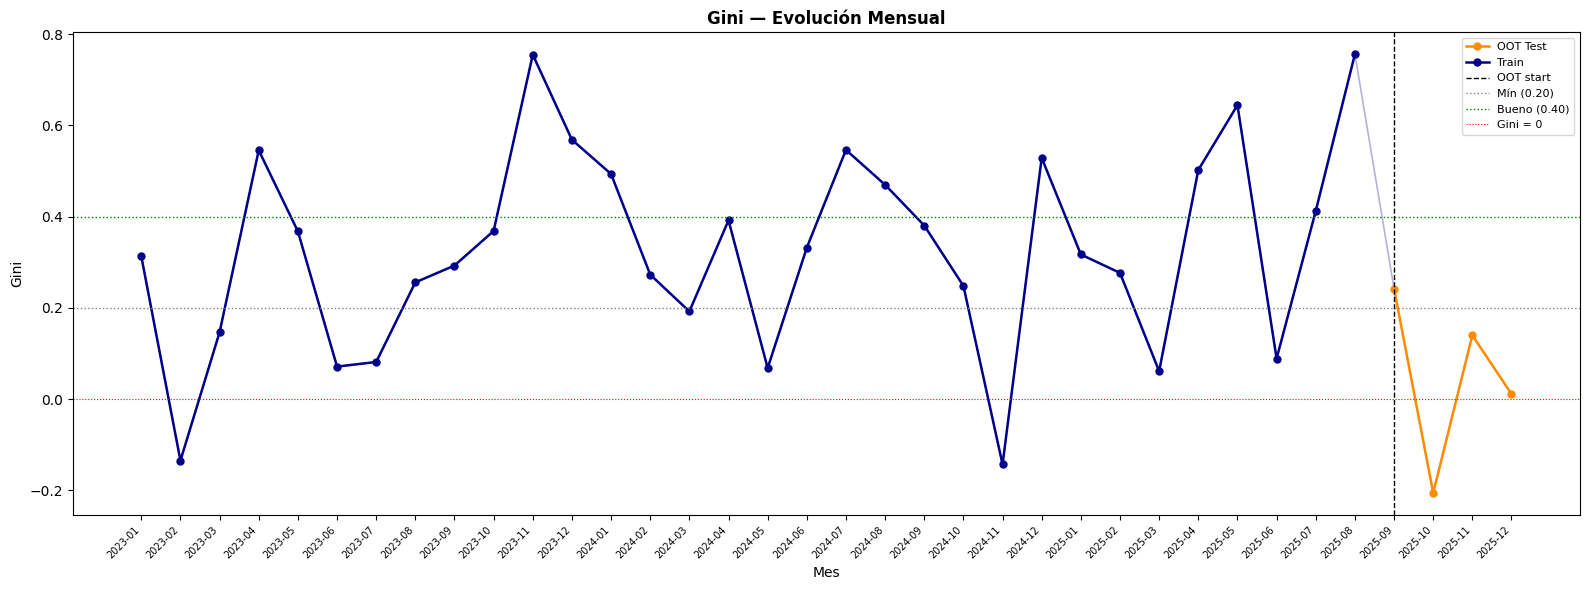

In [12]:
all_months = gini_df['month'].unique().tolist()
month_to_x = {m: i for i, m in enumerate(all_months)}

fig, ax = plt.subplots(figsize=(16, 6))
palette = {'Train': 'darkblue', 'OOT Test': 'darkorange'}

# Línea continua uniendo train + OOT
ax.plot(gini_df['month'].map(month_to_x), gini_df['Gini'],
        color='darkblue', linewidth=1.2, alpha=0.3, zorder=1)

# Puntos por set con color
for label, grp in gini_df.groupby('set'):
    xs = grp['month'].map(month_to_x)
    ax.plot(xs, grp['Gini'], marker='o', markersize=5,
            linewidth=1.8, label=label, color=palette[label], zorder=2)

ax.axvline(month_to_x['2025-09'], color='black', linestyle='--', linewidth=1, label='OOT start')
ax.axhline(0.20, color='grey',  linestyle=':', linewidth=1, label='Mín (0.20)')
ax.axhline(0.40, color='green', linestyle=':', linewidth=1, label='Bueno (0.40)')
ax.axhline(0.00, color='red',   linestyle=':', linewidth=0.8, label='Gini = 0')

ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=7)
ax.set_title('Gini — Evolución Mensual', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Gini')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## **5.4 Distribución del Score: Goods vs Bads**

Un modelo bien calibrado debe mostrar:
- **Scores bajos** concentrados en Buenos (Good = 0)
- **Scores altos** concentrados en Malos (Bad = 1)
- Distribuciones **similares entre Train y OOT** → no hay drift en el score

Si las distribuciones de Good y Bad se superponen mucho, el modelo tiene poco poder discriminatorio.

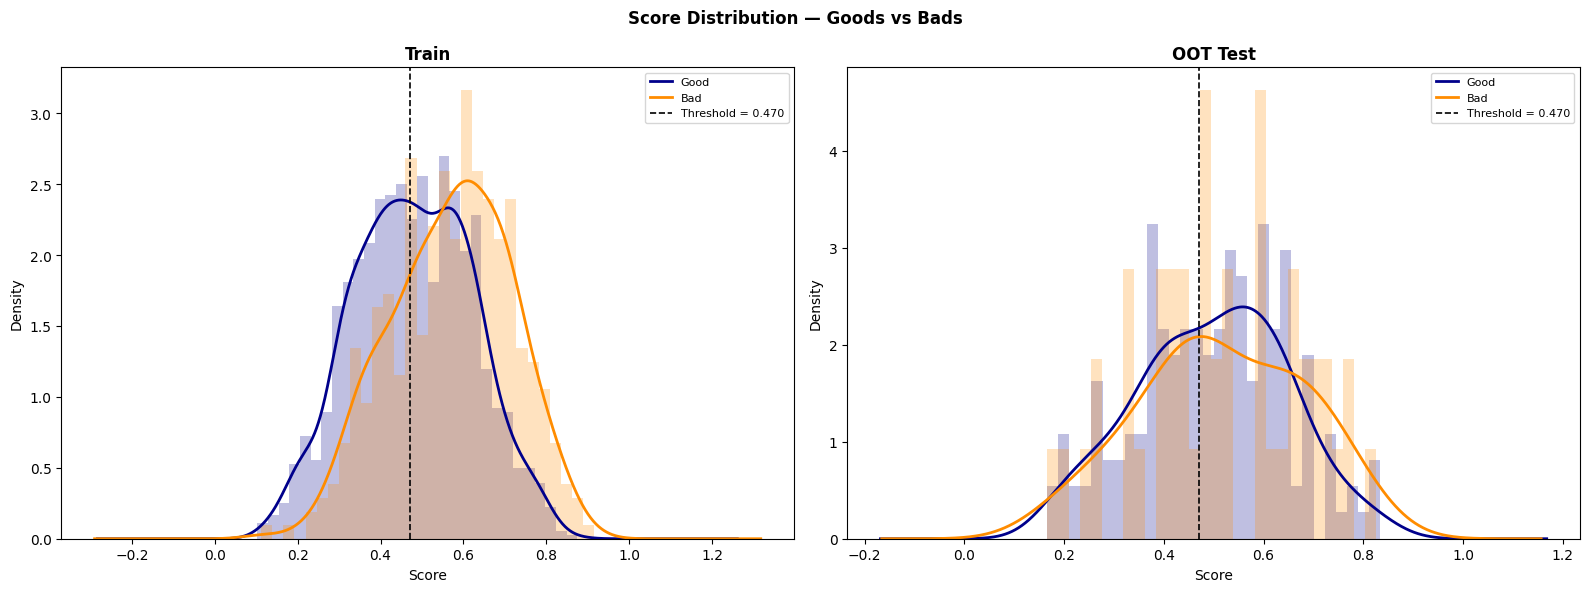

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, df) in zip(axes, [('Train', train), ('OOT Test', test)]):
    for cls, color, name in [(0, 'darkblue', 'Good'), (1, 'darkorange', 'Bad')]:
        subset = df[df[TARGET] == cls]['score']
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=name)
        ax.hist(subset, bins=30, alpha=0.25, color=color, density=True)
    ax.axvline(mdl.threshold, color='black', linestyle='--', linewidth=1.2, label=f'Threshold = {mdl.threshold:.3f}')
    ax.set_title(f'{label}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

fig.suptitle('Score Distribution — Goods vs Bads', fontweight='bold')
plt.tight_layout()
plt.show()